Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

Visualization Palette

In [ ]:
sunset_bliss = sns.color_palette([ "#FF6F61", "#DE3163","#FFAD60", "#6B5B95", "#88B04B", "#92A8D1"])
sns.set_palette(sunset_bliss)

Explore and Visualize data

In [ ]:
df=pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isna().sum()/len(df)*100

,0
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
total_bedrooms,1.002907
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


There is null values in total_bedroom but it is 1% of data so i will drop null values

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Check Outliers

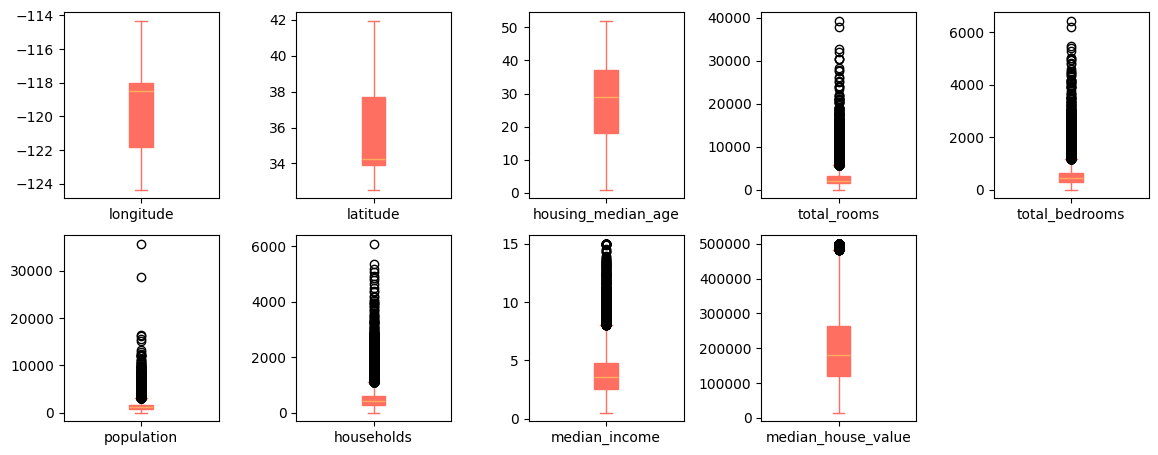

In [ ]:
df.plot(subplots =True, kind = 'box', layout = (5,5), figsize = (14,14),patch_artist=True)
plt.subplots_adjust(wspace = 0.5)

there are alot of outliers in total_rooms, total_bedrooms, population, households,median_income but the oulier in median_income acceptable

Feature Engineering

In [ ]:
df['bedrooms_per_room']=df['total_bedrooms']/df['total_rooms']
df['rooms_per_houshold']=df['total_rooms']/df['households']
df['populations_per_household']=df['population']/df['households']

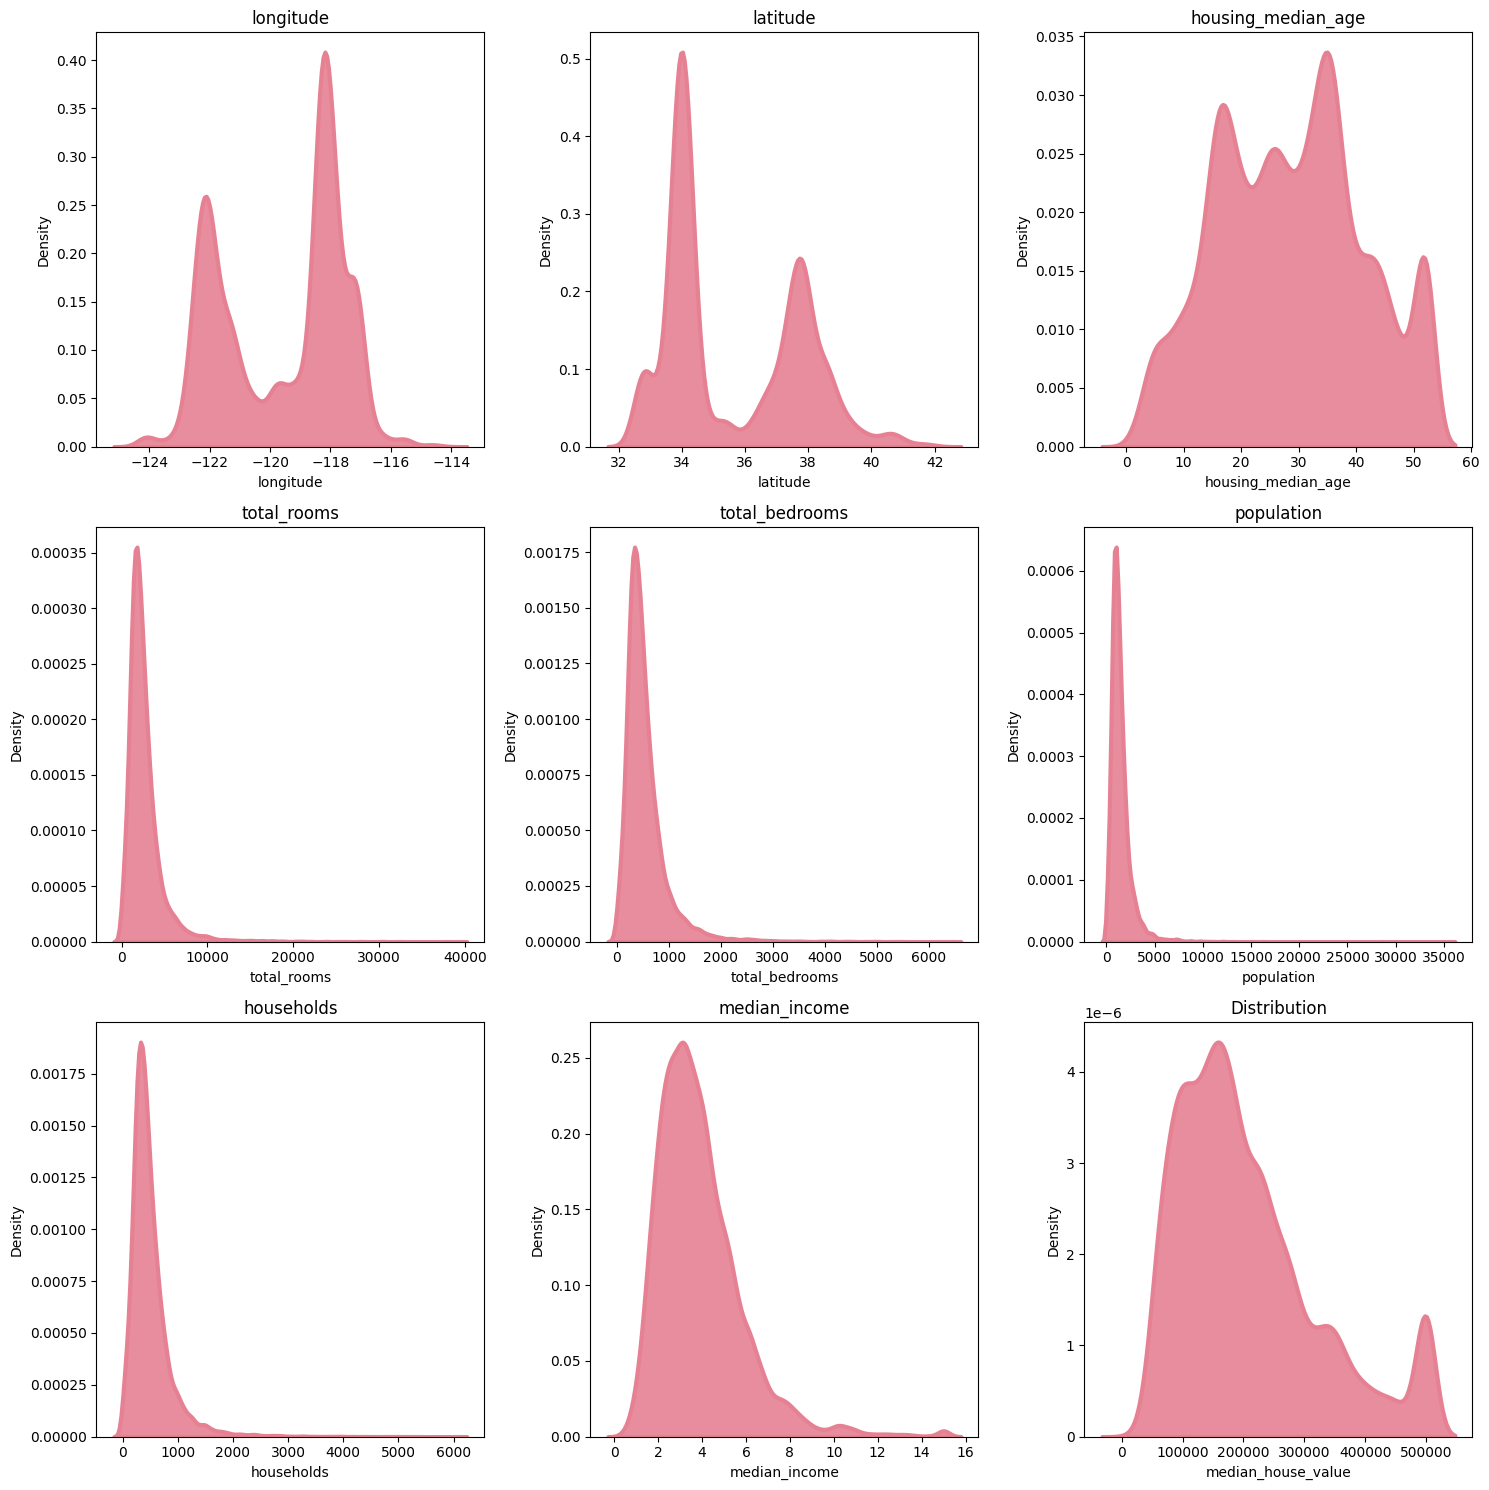

In [ ]:
plt.figure(figsize = (15,15))
for ax, col in enumerate(df.columns[:9]):
    plt.subplot(3,3, ax + 1)
    plt.title(col)
    plotting = sns.kdeplot(x = df[col],fill=True, common_norm=False, color="#E68193",alpha=.9, linewidth=3);

plt.tight_layout()
plt.title('Distribution')
plt.show()

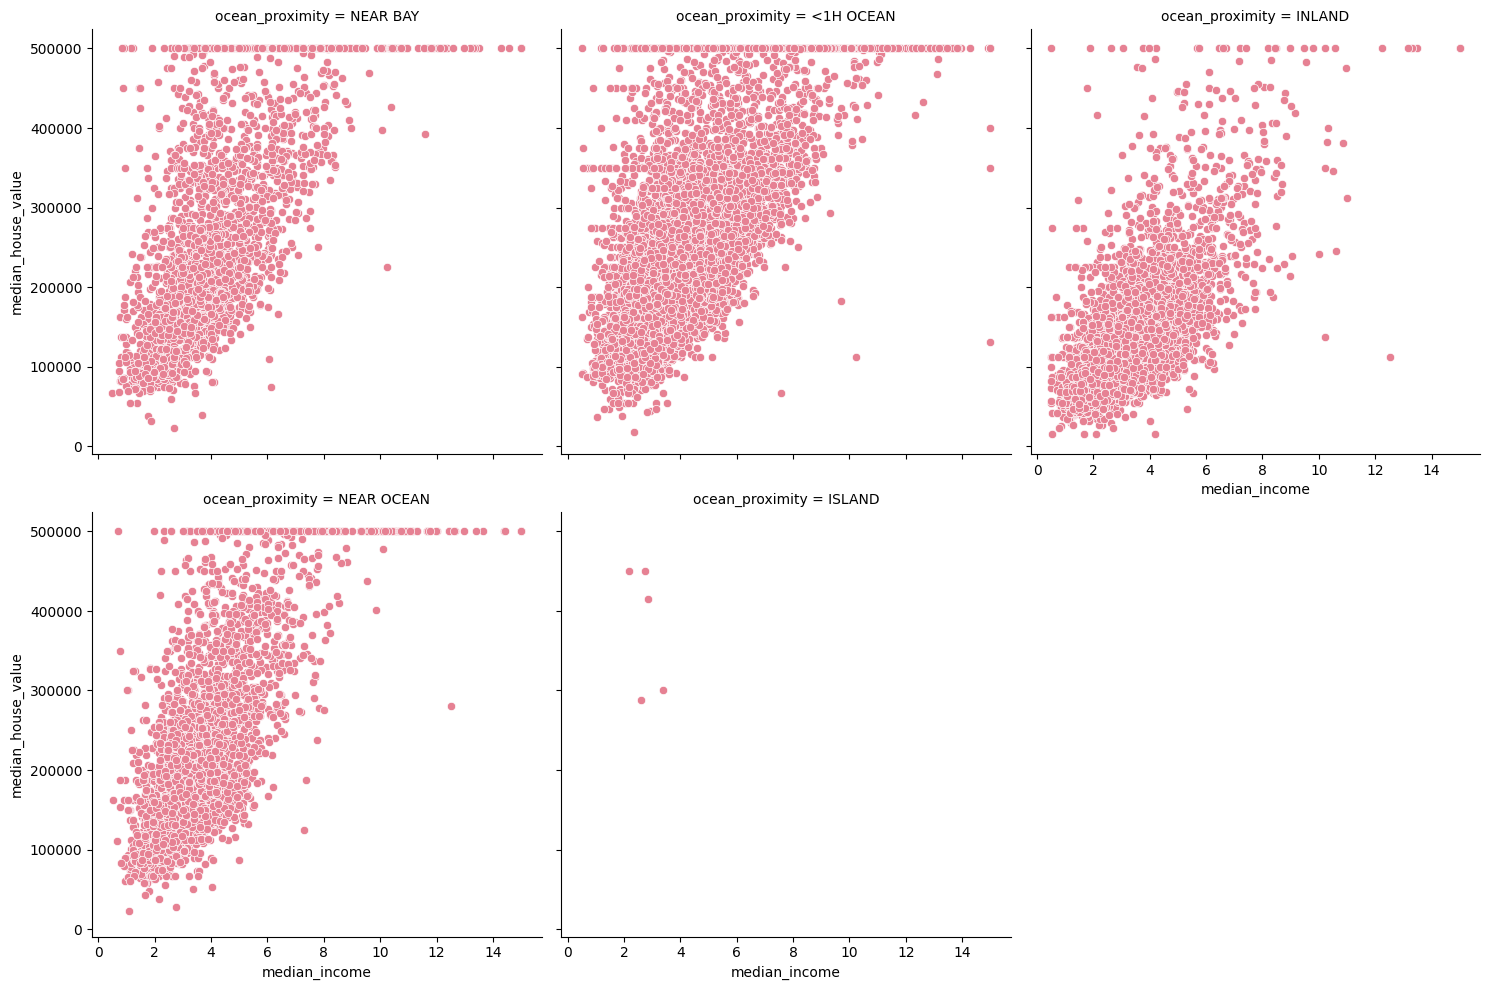

In [ ]:
sns.relplot(x="median_income",y='median_house_value',data=df,col="ocean_proximity",col_wrap=3,color="#E68193")

Text(0.5, 1.0, 'Correlation Matrix')

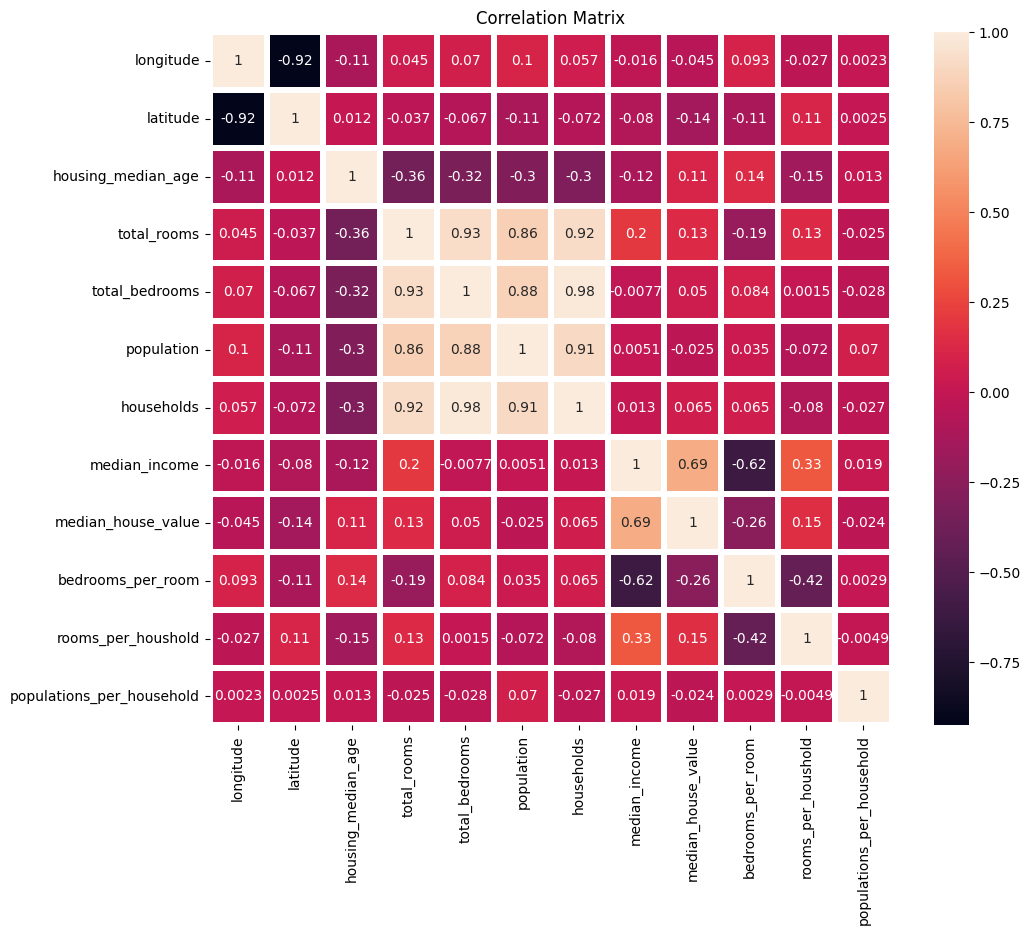

In [ ]:
plt.figure(figsize=(11,9))
data_num = df.select_dtypes(include='number')
sns.heatmap(data_num.corr(), annot=True, fmt='.2g',linewidths=3)
plt.title('Correlation Matrix')

I will apply log

In [ ]:
df["total_rooms"] = np.log1p(df["total_rooms"])
df["total_bedrooms"] = np.log1p(df["total_bedrooms"])
df["population"] = np.log1p(df["population"])
df["households"] = np.log1p(df["households"])
df['median_income'] = np.log1p(df["median_income"])
df["median_house_value"] = np.log1p(df["median_house_value"])

Text(0.5, 1.0, 'Correlation Matrix')

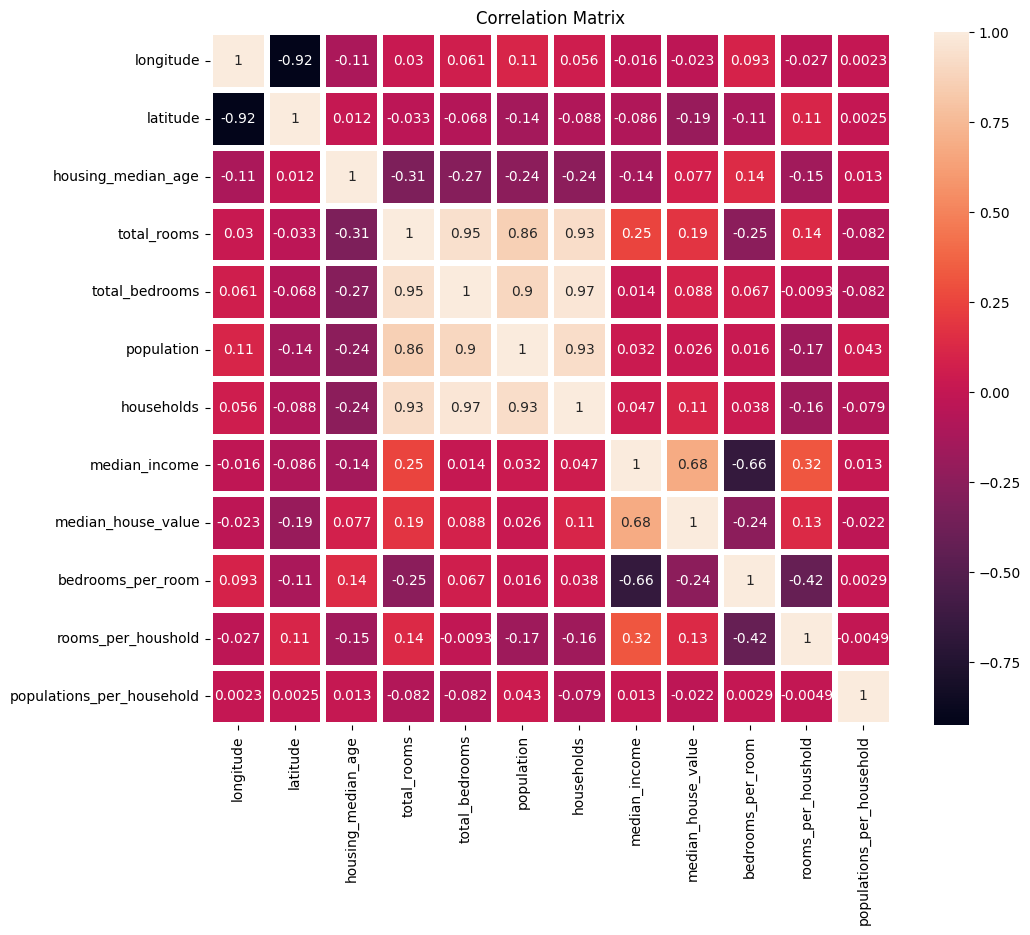

In [ ]:
plt.figure(figsize=(11,9))
data_num = df.select_dtypes(include='number')
sns.heatmap(data_num.corr(), annot=True, fmt='.2g',linewidths=3)
plt.title('Correlation Matrix')

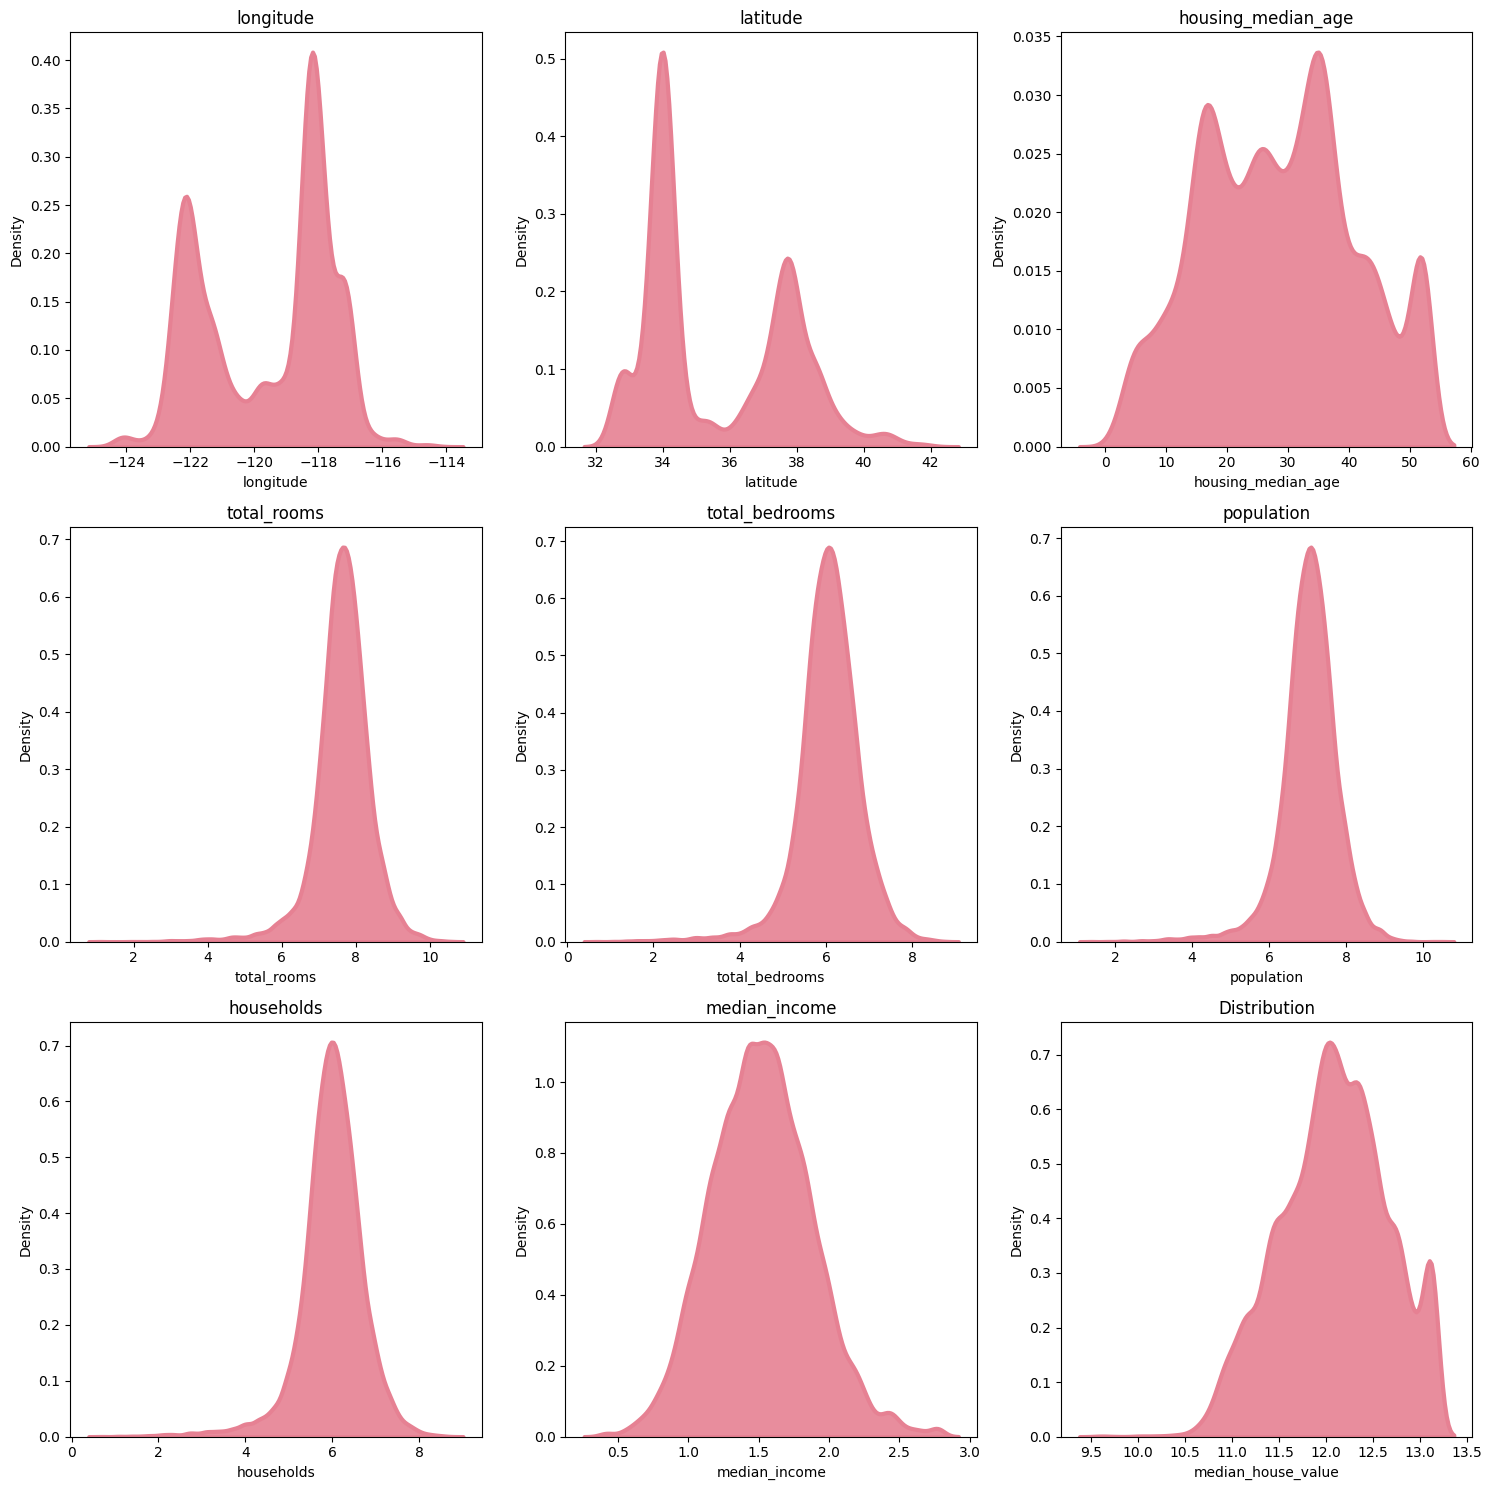

In [ ]:
plt.figure(figsize = (15,15))
for ax, col in enumerate(df.columns[:9]):
    plt.subplot(3,3, ax + 1)
    plt.title(col)
    plotting = sns.kdeplot(x = df[col],fill=True, common_norm=False, color="#E68193",alpha=.9, linewidth=3);

plt.tight_layout()
plt.title('Distribution')
plt.show()

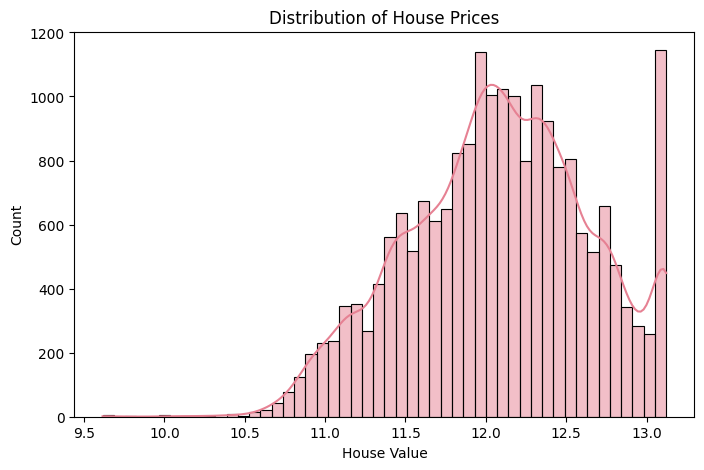

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=50,color="#E68193", kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Value")
plt.show()

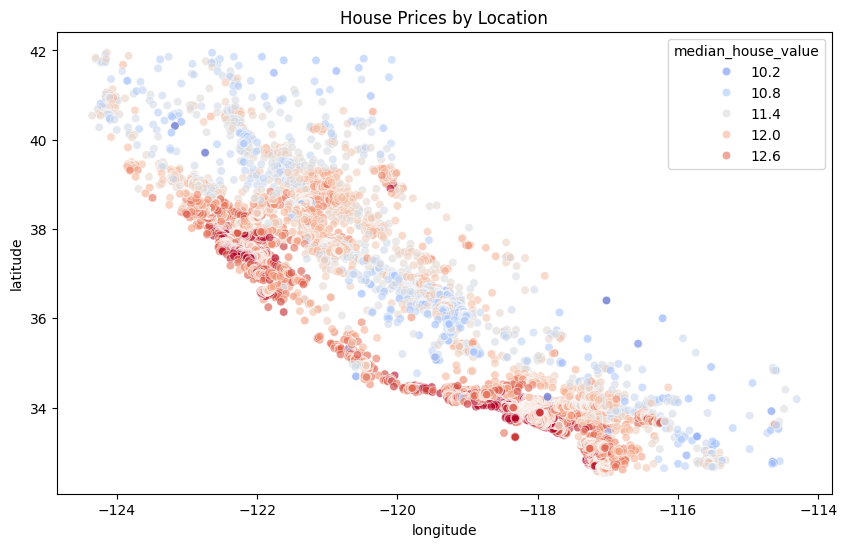

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["longitude"], y=df["latitude"], hue=df["median_house_value"], palette="coolwarm", alpha=0.6)
plt.title("House Prices by Location")
plt.show()

preparing data to model

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,bedrooms_per_room,rooms_per_houshold,populations_per_household
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,2.232720,13.022766,NEAR BAY,0.146591,6.984127,2.555556
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,2.230165,12.789687,NEAR BAY,0.155797,6.238137,2.109842
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,2.111110,12.771673,NEAR BAY,0.129516,8.288136,2.802260
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,1.893579,12.740520,NEAR BAY,0.184458,5.817352,2.547945
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,1.578195,12.743154,NEAR BAY,0.172096,6.281853,2.181467


In [ ]:
x=df.drop(columns=["median_house_value"])
y=df['median_house_value']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
num_col=['longitude','latitude','housing_median_age','total_rooms','total_bedrooms',
         'population','households','median_income','bedrooms_per_room',
         'rooms_per_houshold','populations_per_household']
cat_col=['ocean_proximity']

In [ ]:
num_pipline=Pipeline([('imputer',SimpleImputer(strategy='median')),
                      ("scaler",StandardScaler())])

In [ ]:
cat_pipline= Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor=ColumnTransformer([
    ("num",num_pipline,num_col),
    ("cat",cat_pipline,cat_col)
])

First model-> Liner regression

In [ ]:
model_1=Pipeline([
    ("preprocessor",preprocessor),
    ("regressor",LinearRegression())
])
model_1.fit(X_train,y_train)
y_pred_1=model_1.predict(X_test)

mae_1 = mean_absolute_error(y_test, y_pred_1)
rmse_1 = mean_squared_error(y_test, y_pred_1)
rmse_1=np.sqrt(rmse_1)
r2_1 = r2_score(y_test, y_pred_1)

print(f"MAE: {mae_1:.2f}")
print(f"RMSE: {rmse_1:.2f}")
print(f"R² Score: {r2_1:.4f}")

MAE: 0.23
RMSE: 0.31
R² Score: 0.7111


Second model-> Random forest regressor

In [ ]:
model_2 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
mae_2 = mean_absolute_error(y_test, y_pred_2)
rmse_2 = mean_squared_error(y_test, y_pred_2)
rmse_2=np.sqrt(rmse_2)
r2_2 = r2_score(y_test, y_pred_2)

print(f"MAE: {mae_2:.2f}")
print(f"RMSE: {rmse_2:.2f}")
print(f"R² Score: {r2_2:.4f}")

MAE: 0.16
RMSE: 0.23
R² Score: 0.8369


Third model->Decision Tree Regressor

In [ ]:
model_3 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=10, random_state=42))
])

model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)

mae_3 = mean_absolute_error(y_test, y_pred_3)
rmse_3 = mean_squared_error(y_test, y_pred_3)
rmse_3=np.sqrt(rmse_3)
r2_3 = r2_score(y_test, y_pred_3)

print(f"MAE: {mae_3:.2f}")
print(f"RMSE: {rmse_3:.2f}")
print(f"R² Score: {r2_3:.4f}")

MAE: 0.21
RMSE: 0.30
R² Score: 0.7294


In [ ]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,bedrooms_per_room,rooms_per_houshold,populations_per_household
14416,-117.24,32.79,20.0,6.869014,5.631212,6.265301,5.541264,1.431220,NEAR OCEAN,0.289282,3.783465,2.066929
16383,-121.29,38.01,2.0,8.764678,7.018402,8.110127,6.864848,1.702400,INLAND,0.174293,6.690700,3.476489
7731,-118.14,33.92,31.0,8.224700,6.749931,7.746733,6.687109,1.440712,<1H OCEAN,0.228625,4.657928,2.887640
1410,-122.07,37.94,30.0,7.139660,5.624018,6.562444,5.402677,1.358923,NEAR BAY,0.219048,5.701357,3.199095
1335,-121.89,37.99,4.0,7.683404,6.393591,6.834109,6.135565,1.629554,INLAND,0.274988,4.709328,2.013015
...,...,...,...,...,...,...,...,...,...,...,...,...
8291,-118.15,33.76,36.0,7.978311,6.666957,7.076654,6.620073,1.525730,NEAR OCEAN,0.269204,3.893191,1.579439
6274,-117.95,34.03,33.0,7.486053,5.978886,7.325149,5.932245,1.467621,<1H OCEAN,0.221100,4.739362,4.034574
2997,-119.03,35.32,12.0,7.909122,6.309918,7.166266,6.261492,1.269058,INLAND,0.201764,5.202677,2.474187
13440,-117.42,34.08,28.0,7.741099,6.040255,7.180070,6.098074,1.500605,INLAND,0.182174,5.180180,2.954955


So the best model Random Forest Regressor

In [ ]:
import joblib

joblib.dump(model_2, "random_forest_model.pkl")

In [ ]:
from google.colab import files
files.download('random_forest_model.pkl')

In [ ]:
#pipeline = Pipeline([
#   ('preprocessing', preprocessor),
#    ('model', RandomForestRegressor())
#])

In [ ]:
#categorical_feature_names = pipeline.named_steps['preprocessing'] \
 #   .named_transformers_['cat'] \
  #  .named_steps['encoder'] \
   # .get_feature_names_out(cat_col)

# دمج الأعمدة الرقمية مع التصنيفية
#final_feature_names = list(num_col) + list(categorical_feature_names)

#print(final_feature_names)